In [ ]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Clustering
from sklearn.cluster import KMeans

# PCA
from sklearn.decomposition import PCA

# Model Saving
import pickle

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("diamonds.csv")

Saving diamonds.csv to diamonds.csv


In [ ]:
# Load Dataset

df = pd.read_csv("diamonds.csv")

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.shape

(53940, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
(df[['x', 'y', 'z']] == 0).sum()

,0
x,8
y,7
z,20


In [ ]:
# Replace zero values with NaN
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)

# Fill NaN with median
df[['x','y','z']] = df[['x','y','z']].fillna(df[['x','y','z']].median())

# Verify
(df[['x','y','z']] == 0).sum()

,0
x,0
y,0
z,0


**Convert Price from USD to INR**

In [ ]:
usd_to_inr = 87

df["price_inr"] = df["price"] * usd_to_inr

df[['price','price_inr']].head()

,price,price_inr
0,326,28362
1,326,28362
2,327,28449
3,334,29058
4,335,29145


**Step 9 – Feature Engineering**

In [ ]:
# Volume
df["volume"] = df["x"] * df["y"] * df["z"]

# Price Per Carat
df["price_per_carat"] = df["price"] / df["carat"]

# Dimension Ratio
df["dimension_ratio"] = (df["x"] + df["y"]) / (2 * df["z"])

In [ ]:
def carat_category(carat):
    if carat < 0.5:
        return "Light"
    elif carat <= 1.5:
        return "Medium"
    else:
        return "Heavy"

df["carat_category"] = df["carat"].apply(carat_category)

In [ ]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,28362,38.202030,1417.391304,1.631687,Light
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,28362,34.505856,1552.380952,1.673160,Light
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,28449,38.076885,1421.739130,1.757576,Light
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,29058,46.724580,1151.724138,1.602662,Light
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,29145,51.917250,1080.645161,1.580000,Light


In [ ]:
df.to_csv("diamonds_cleaned.csv", index=False)

Next Step (EDA)

The project expects multiple visualizations. We'll create them efficiently:

Distribution plots
Boxplots
Countplots
Heatmap
Pairplot
Scatter plots
Regression plots
Bar charts

This will satisfy the EDA requirements while producing professional-looking outputs for your submission.


Step 11 – Set Visualization Style

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Increase default figure size
plt.rcParams["figure.figsize"] = (8,5)

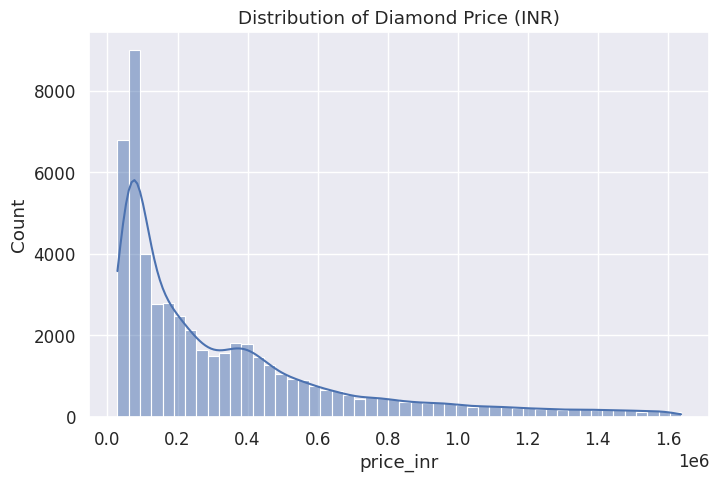

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["price_inr"], bins=50, kde=True)
plt.title("Distribution of Diamond Price (INR)")
plt.show()

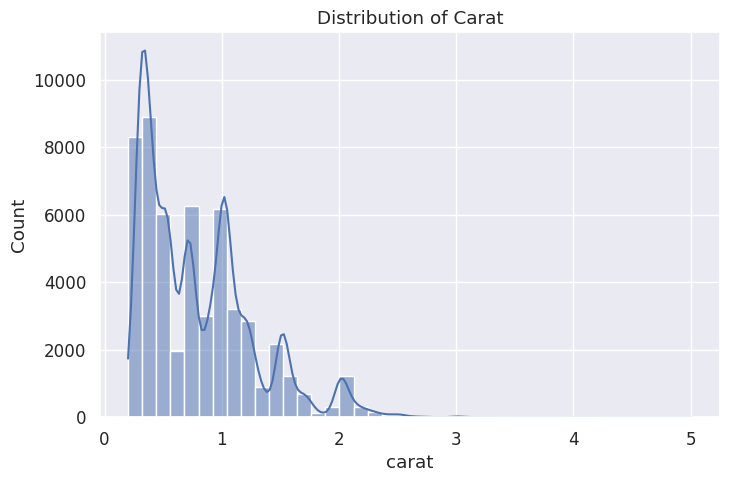

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["carat"], bins=40, kde=True)
plt.title("Distribution of Carat")
plt.show()

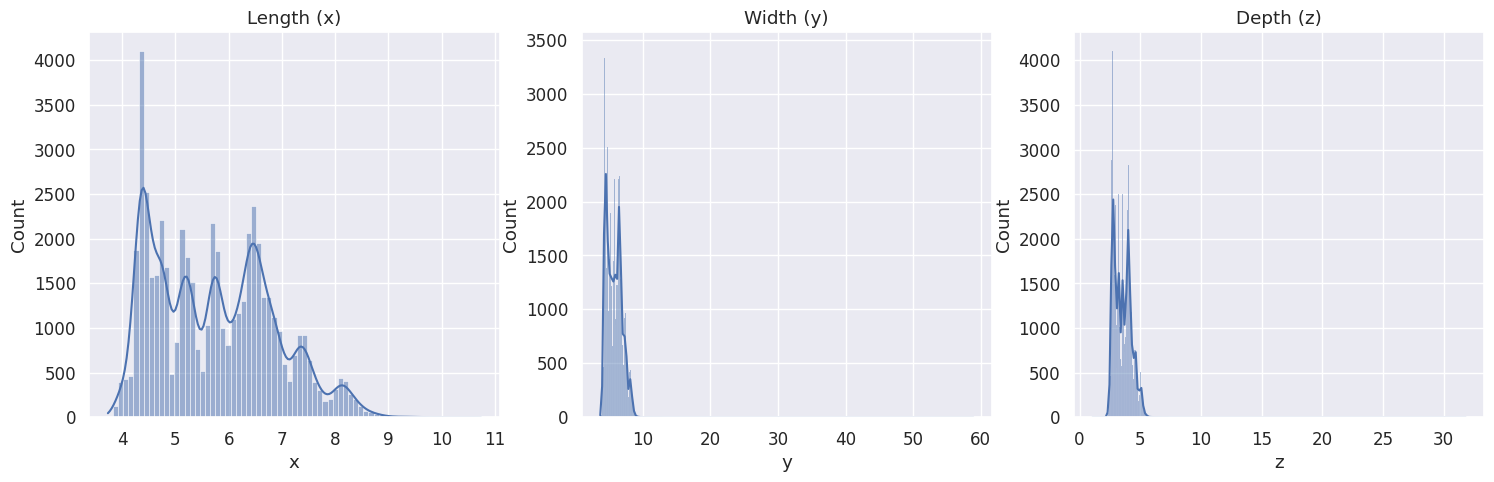

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(df["x"], kde=True, ax=axes[0])
axes[0].set_title("Length (x)")

sns.histplot(df["y"], kde=True, ax=axes[1])
axes[1].set_title("Width (y)")

sns.histplot(df["z"], kde=True, ax=axes[2])
axes[2].set_title("Depth (z)")

plt.show()

Step 13 – Count Plots

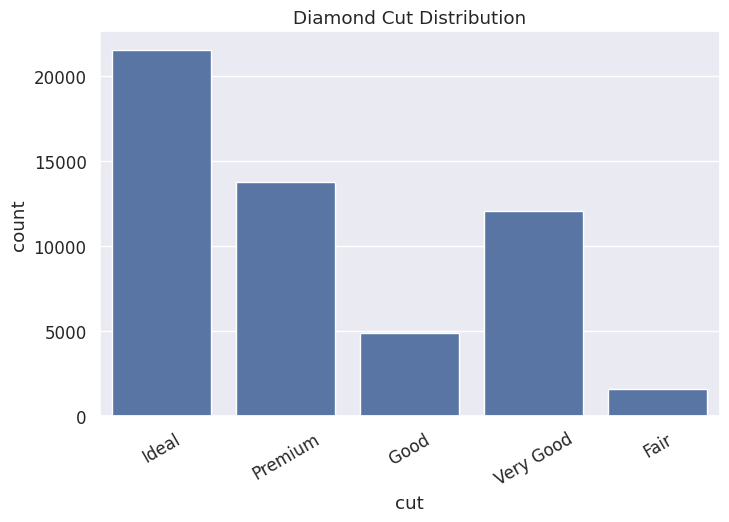

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="cut")
plt.title("Diamond Cut Distribution")
plt.xticks(rotation=30)
plt.show()

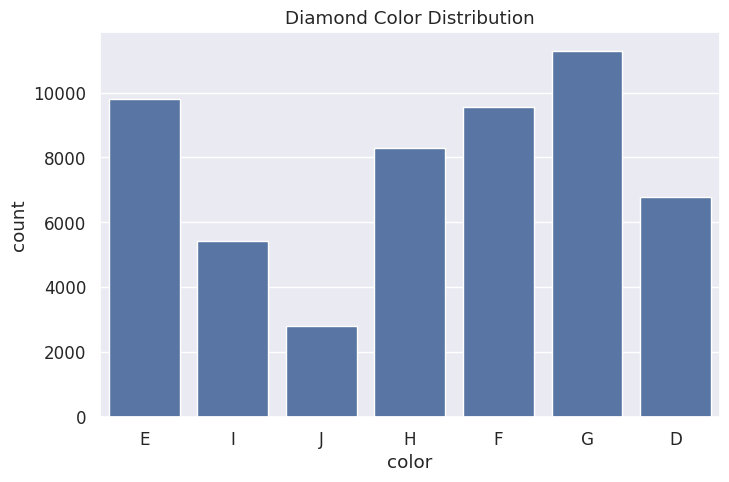

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="color")
plt.title("Diamond Color Distribution")
plt.show()

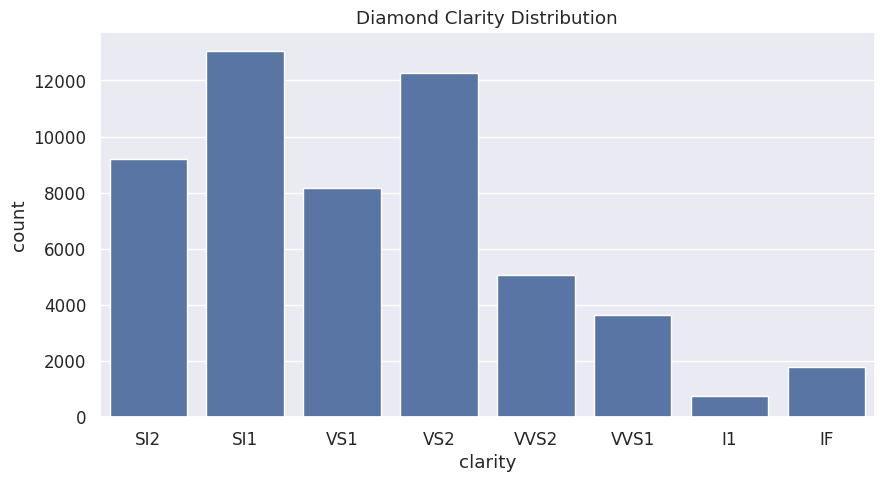

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="clarity")
plt.title("Diamond Clarity Distribution")
plt.show()

Step 14 – Boxplots

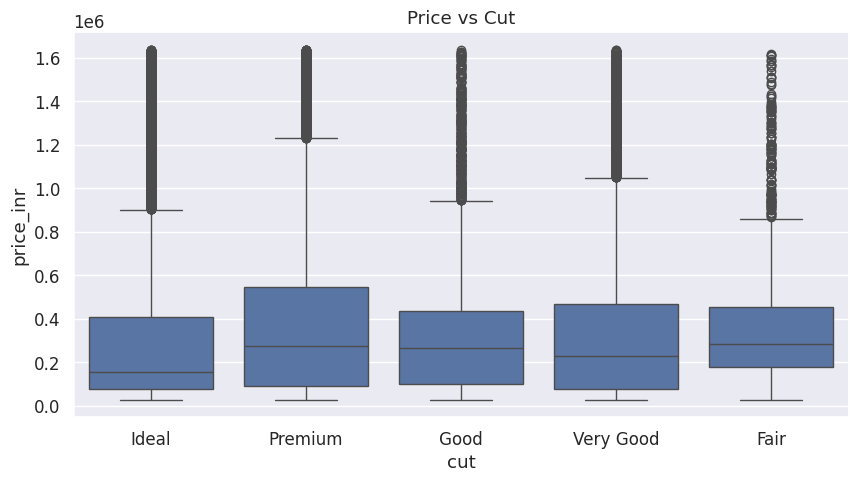

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="cut", y="price_inr")
plt.title("Price vs Cut")
plt.show()

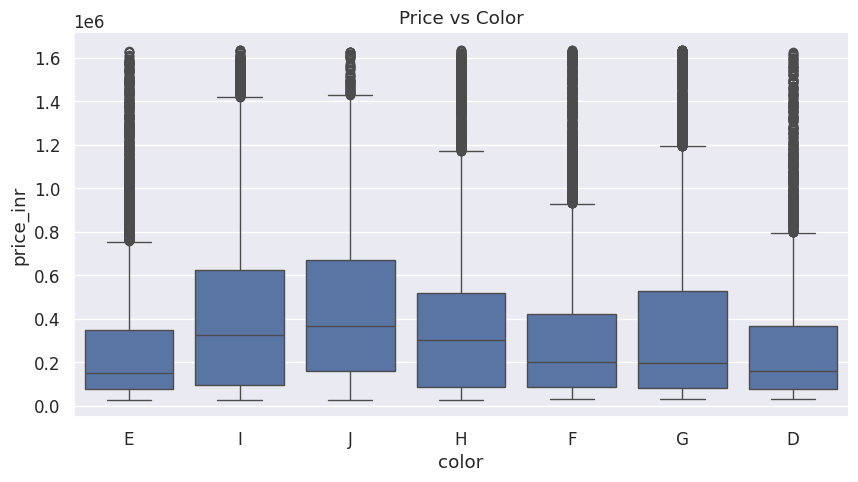

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="color", y="price_inr")
plt.title("Price vs Color")
plt.show()

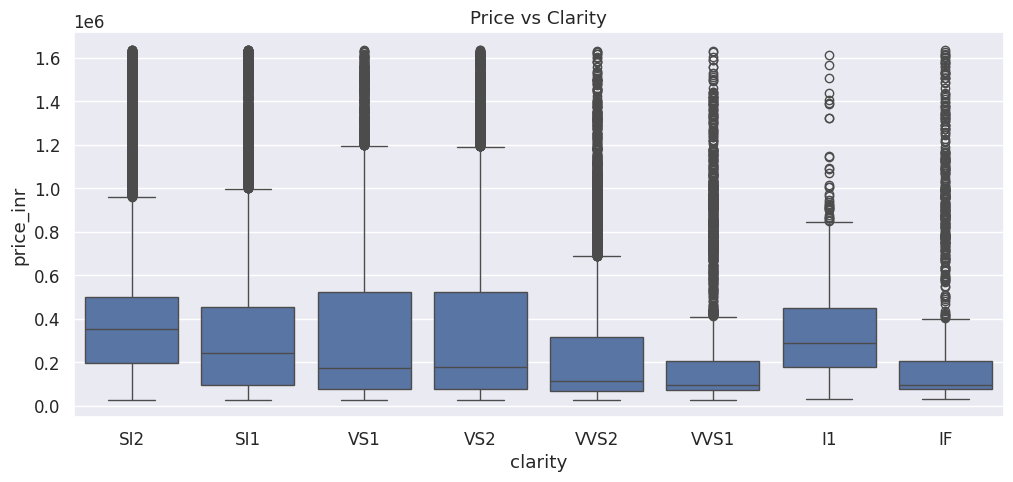

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="clarity", y="price_inr")
plt.title("Price vs Clarity")
plt.show()

**Step 15 – Correlation Heatmap**

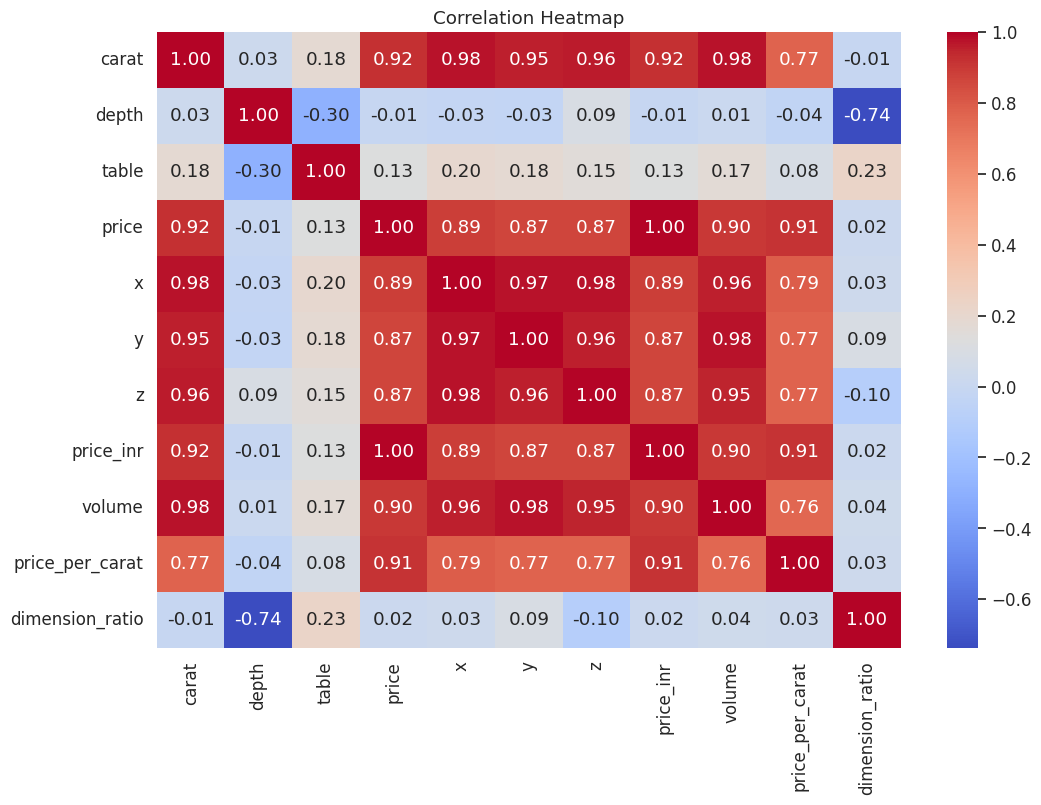

In [ ]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

**Step 16 – Scatter Plot**

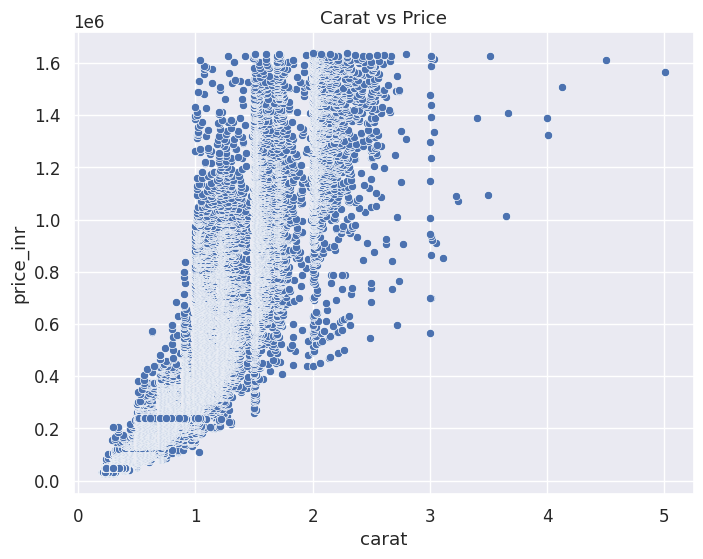

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="carat", y="price_inr")
plt.title("Carat vs Price")
plt.show()

**Step 17 – Regression Plot**

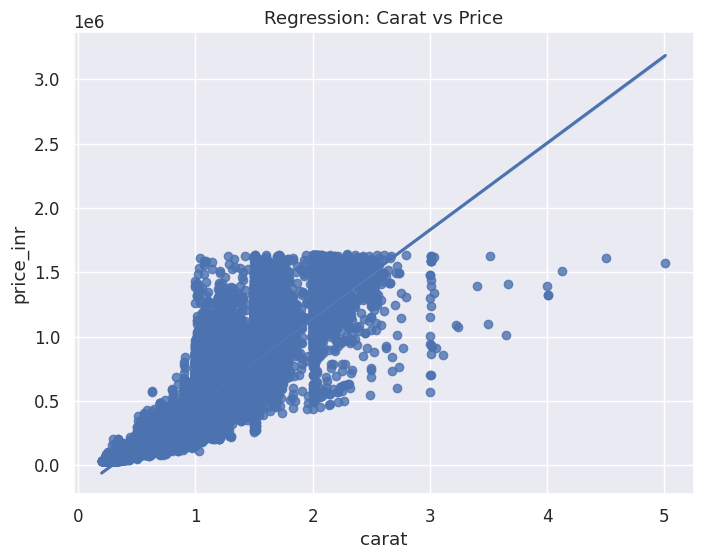

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="carat", y="price_inr")
plt.title("Regression: Carat vs Price")
plt.show()

**Step 18 – Pairplot**

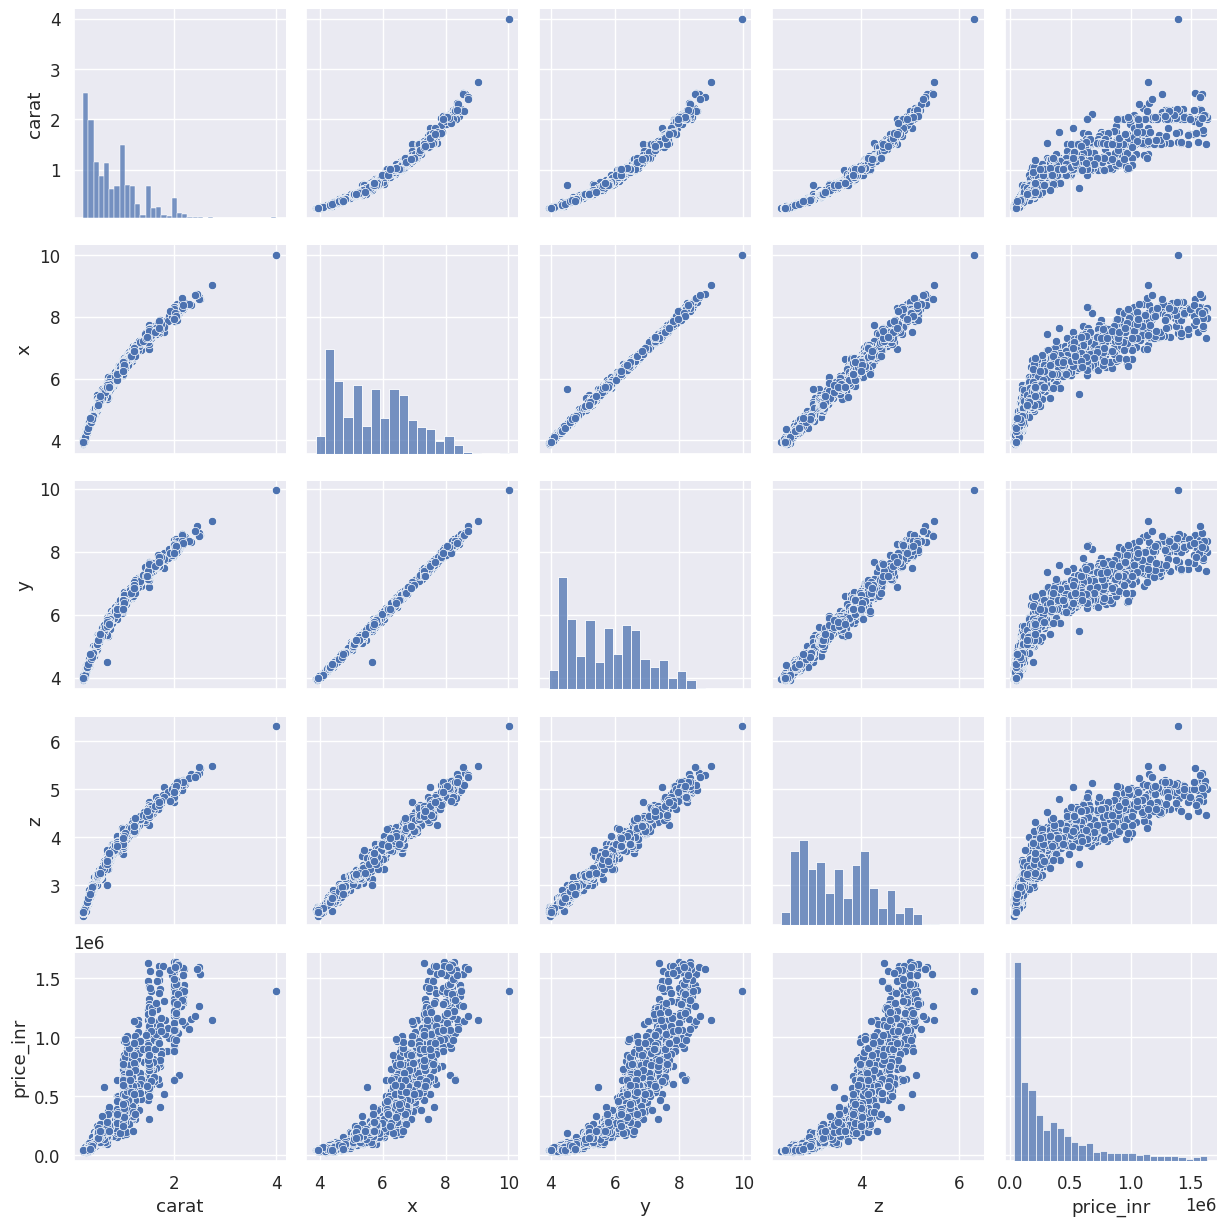

In [ ]:
sample_df = df.sample(2000, random_state=42)

sns.pairplot(
    sample_df[
        ["carat","x","y","z","price_inr"]
    ]
)

plt.show()

**Step 19 – Average Price by Cut**

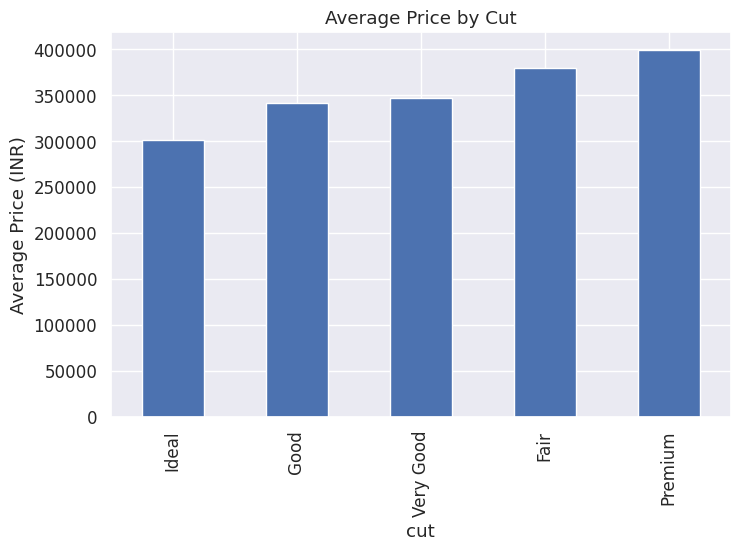

In [ ]:
avg_cut = df.groupby("cut")["price_inr"].mean().sort_values()

avg_cut.plot(kind="bar", figsize=(8,5))

plt.title("Average Price by Cut")
plt.ylabel("Average Price (INR)")
plt.show()

Step 20 – Average Price by Color

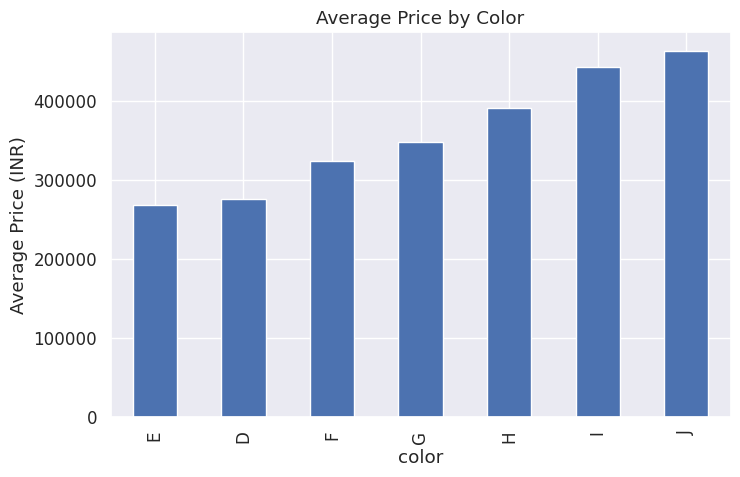

In [ ]:
avg_color = df.groupby("color")["price_inr"].mean().sort_values()

avg_color.plot(kind="bar", figsize=(8,5))

plt.title("Average Price by Color")
plt.ylabel("Average Price (INR)")
plt.show()

Step 21 – Average Price by Clarity

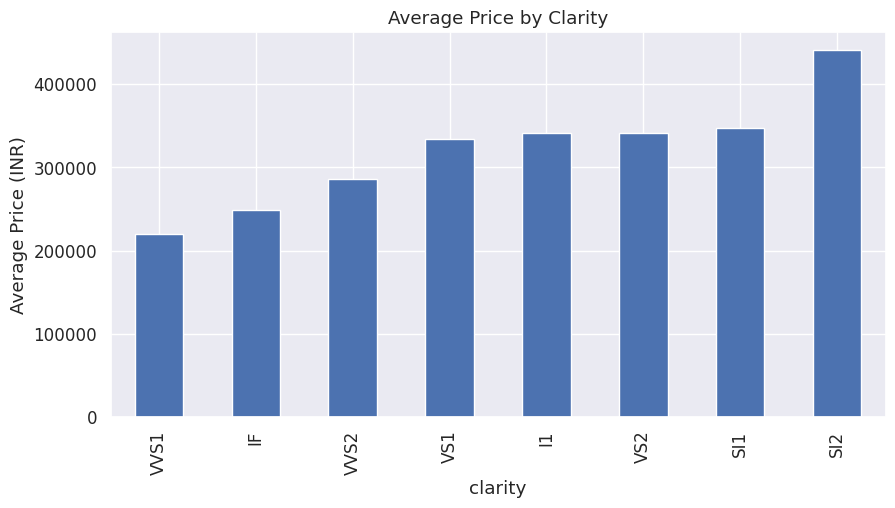

In [ ]:
avg_clarity = df.groupby("clarity")["price_inr"].mean().sort_values()

avg_clarity.plot(kind="bar", figsize=(10,5))

plt.title("Average Price by Clarity")
plt.ylabel("Average Price (INR)")
plt.show()

Machine Learning

Step 22 – Outlier Handling (IQR Method)

In [ ]:
# Select numerical columns
numerical_cols = ['carat', 'depth', 'table', 'price_inr', 'x', 'y', 'z', 'volume']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(46525, 15)


Step 23 – Skewness Check

In [ ]:
skewness = df[numerical_cols].skew()
print(skewness)

carat        0.677308
depth       -0.198084
table        0.397107
price_inr    1.143362
x            0.251685
y            0.245210
z            0.247739
volume       0.676728
dtype: float64


Step 24 – Log Transformation

In [ ]:
import numpy as np

df["price_inr"] = np.log1p(df["price_inr"])
df["carat"] = np.log1p(df["carat"])
df["volume"] = np.log1p(df["volume"])

Step 25 – Encode Categorical Columns

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cut_order = ['Fair','Good','Very Good','Premium','Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

encoder = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order]
)

df[['cut','color','clarity']] = encoder.fit_transform(
    df[['cut','color','clarity']]
)

Step 26 – Feature Selection

In [ ]:
features = [
    'carat',
    'cut',
    'color',
    'clarity',
    'depth',
    'table',
    'x',
    'y',
    'z',
    'volume',
    'dimension_ratio'
]

X = df[features]

y = df['price_inr']

Step 27 – Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 28 – Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 29 – Build 5 Regression Models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(random_state=42)

Step 30 – Train & Evaluate Models

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values("R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
4,XGBoost,0.060378,0.006863,0.082845,0.991742
2,Random Forest,0.059989,0.007129,0.084432,0.991423
1,Decision Tree,0.080224,0.013857,0.117717,0.983327
3,KNN,0.093764,0.015399,0.124092,0.981473
0,Linear Regression,0.107381,0.018809,0.137146,0.977369


Step 31 – Save the Best Model

In [ ]:
best_model = RandomForestRegressor(random_state=42)

best_model.fit(X_train, y_train)

import pickle

pickle.dump(best_model, open("price_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(encoder, open("encoder.pkl", "wb"))

Step 32 – Artificial Neural Network (ANN)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

**Build the ANN Model**

In [ ]:
ann = Sequential()

# Input Layer
ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 1
ann.add(Dense(32, activation='relu'))

# Hidden Layer 2
ann.add(Dense(16, activation='relu'))

# Output Layer
ann.add(Dense(1))

Compile the Model

In [ ]:
ann.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

**Train the Model**

In [ ]:
history = ann.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 10.1541 - mae: 1.6629 - val_loss: 0.4472 - val_mae: 0.4799
Epoch 2/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3184 - mae: 0.2782 - val_loss: 0.0792 - val_mae: 0.1665
Epoch 3/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0656 - mae: 0.1505 - val_loss: 0.0365 - val_mae: 0.1371
Epoch 4/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0342 - mae: 0.1302 - val_loss: 0.0242 - val_mae: 0.1190
Epoch 5/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0251 - mae: 0.1182 - val_loss: 0.0220 - val_mae: 0.1161
Epoch 6/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0207 - mae: 0.1103 - val_loss: 0.0212 - val_mae: 0.1120
Epoch 7/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0187 - mae: 0.1059 - val_loss: 0.0161 - val_mae: 0.0968
Epoch 8/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0191 - mae: 0.1038 - val_loss: 0.0161 - val_mae: 0.0986
Epoch 9/50
931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - l

In [ ]:
ann_pred = ann.predict(X_test)

291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, ann_pred)
mse = mean_squared_error(y_test, ann_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ann_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 0.07130660948957525
MSE : 0.014392958266812689
RMSE : 0.1199706558572249
R2 : 0.9826827620688758


In [ ]:
ann.save("ann_model.keras")

**Step 33 – K-Means Clustering**

In [ ]:
cluster_features = [
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
    "volume",
    "dimension_ratio"
]

cluster_df = df[cluster_features]

In [ ]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_df)

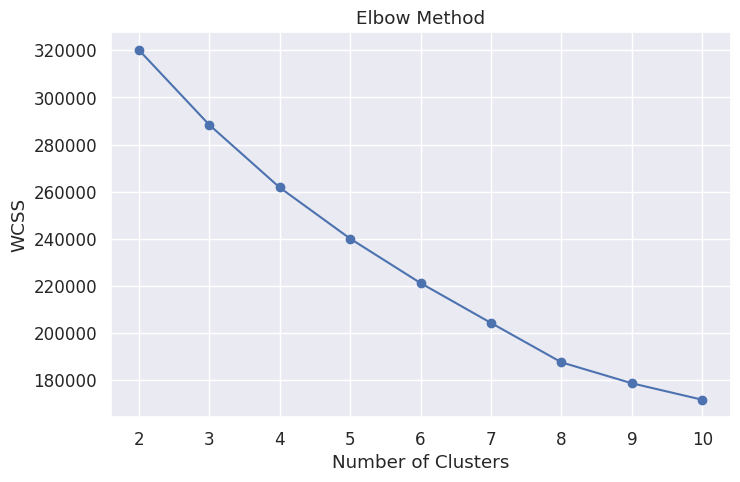

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(cluster_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

df["Cluster"] = clusters

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.2635357288645


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(cluster_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

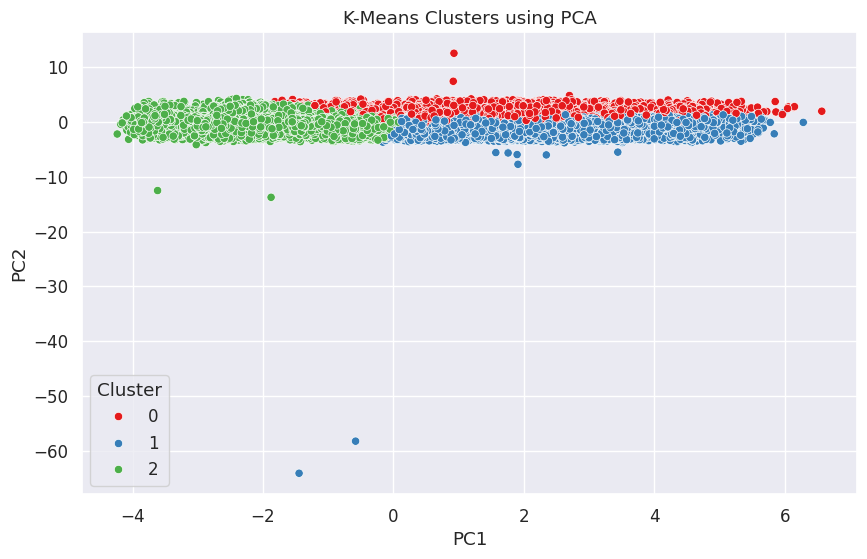

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clusters using PCA")
plt.show()

In [ ]:
df.groupby("Cluster")[["carat","price_inr"]].mean()

,carat,price_inr
Cluster,,
0,0.632543,12.619016
1,0.709718,12.956935
2,0.332039,11.319050


In [ ]:
cluster_names = {
    0: "Affordable Small Diamonds",
    1: "Mid-range Balanced Diamonds",
    2: "Premium Heavy Diamonds"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

df[["Cluster","Cluster_Name"]].head()

,Cluster,Cluster_Name
0,2,Premium Heavy Diamonds
1,2,Premium Heavy Diamonds
3,2,Premium Heavy Diamonds
4,2,Premium Heavy Diamonds
5,2,Premium Heavy Diamonds


In [ ]:
import pickle

pickle.dump(kmeans, open("cluster_model.pkl","wb"))
pickle.dump(cluster_scaler, open("cluster_scaler.pkl","wb"))

**Install Streamlit**

In [ ]:
%%writefile app.py

Writing app.py


Part 1 – Imports, UI Setup, CSS, Sidebar & Model Loading

In [ ]:
# ==========================================
# 💎 Diamond Dynamics
# Price Prediction & Market Segmentation
# GUVI HCL Mini Project
# ==========================================

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf

from PIL import Image
import plotly.express as px
import plotly.graph_objects as go

# ==========================================
# Page Configuration
# ==========================================

st.set_page_config(
    page_title="💎 Diamond Dynamics",
    page_icon="💎",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ==========================================
# Custom CSS
# ==========================================

st.markdown("""
<style>

.main{
    background-color:#F7F9FC;
}

.block-container{
    padding-top:2rem;
}

h1{
    color:#1E3A8A;
    font-weight:bold;
}

h2{
    color:#2563EB;
}

h3{
    color:#1E40AF;
}

.sidebar .sidebar-content{
    background:#111827;
}

.metric-card{
    background:white;
    padding:20px;
    border-radius:15px;
    box-shadow:0px 0px 10px rgba(0,0,0,0.15);
}

.prediction-card{

    background:#EEF7FF;

    padding:20px;

    border-radius:15px;

    border-left:6px solid #2563EB;

}

.footer{

text-align:center;

padding:20px;

color:gray;

}

</style>
""",unsafe_allow_html=True)

# ==========================================
# Title
# ==========================================

st.title("💎 Diamond Dynamics")

st.markdown(
"""
### Price Prediction & Market Segmentation

Artificial Intelligence & Machine Learning Project

**GUVI | HCLTech**
"""
)

# ==========================================
# Load Models
# ==========================================

@st.cache_resource
def load_models():

    price_model=pickle.load(open("price_model.pkl","rb"))

    cluster_model=pickle.load(open("cluster_model.pkl","rb"))

    scaler=pickle.load(open("scaler.pkl","rb"))

    cluster_scaler=pickle.load(open("cluster_scaler.pkl","rb"))

    encoder=pickle.load(open("encoder.pkl","rb"))

    ann_model=tf.keras.models.load_model("ann_model.keras")

    return (
        price_model,
        cluster_model,
        scaler,
        cluster_scaler,
        encoder,
        ann_model
    )

(
price_model,
cluster_model,
scaler,
cluster_scaler,
encoder,
ann_model
)=load_models()

# ==========================================
# Load Dataset
# ==========================================

@st.cache_data
def load_data():

    df=pd.read_csv("diamonds_cleaned.csv")

    return df

df=load_data()

# ==========================================
# Sidebar
# ==========================================

st.sidebar.image(
"https://cdn-icons-png.flaticon.com/512/616/616494.png",
width=100
)

st.sidebar.title("Navigation")

page=st.sidebar.radio(

"Go To",

[
"🏠 Home",

"💎 Price Prediction",

"🎯 Market Segmentation",

"📊 EDA Dashboard",

"📈 Model Performance",

"ℹ About Project"
]

)

st.sidebar.markdown("---")

st.sidebar.success("GUVI HCL Mini Project")

st.sidebar.write("Machine Learning")

st.sidebar.write("Regression")

st.sidebar.write("ANN")

st.sidebar.write("K-Means Clustering")

st.sidebar.write("PCA")

# ==========================================
# Feature Engineering Function
# ==========================================

def preprocess_input(

carat,

cut,

color,

clarity,

depth,

table,

x,

y,

z

):

    volume=x*y*z

    dimension_ratio=(x+y)/(2*z)

    data=pd.DataFrame({

        "cut":[cut],

        "color":[color],

        "clarity":[clarity]

    })

    data[["cut","color","clarity"]]=encoder.transform(

        data[["cut","color","clarity"]]

    )

    features=np.array([[

        carat,

        data["cut"][0],

        data["color"][0],

        data["clarity"][0],

        depth,

        table,

        x,

        y,

        z,

        volume,

        dimension_ratio

    ]])

    return features

2026-08-09 14:17:30.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:17:30.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:17:30.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:17:30.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:17:30.656 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:17:30.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:17:30.659 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:17:30.660 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

💎 PART 2 – Home Dashboard

In [ ]:
# ==========================================================
# 🏠 HOME PAGE
# ==========================================================

if page == "🏠 Home":

    st.markdown("# 🏠 Diamond Analytics Dashboard")

    st.write("Welcome to the **Diamond Dynamics** application developed for the **GUVI HCL Machine Learning Mini Project**.")

    st.markdown("---")

    # ==========================
    # KPI CARDS
    # ==========================

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            "Total Diamonds",
            f"{len(df):,}"
        )

    with col2:
        st.metric(
            "Average Price (INR)",
            f"₹ {df['price_inr'].mean():,.0f}"
        )

    with col3:
        st.metric(
            "Average Carat",
            round(df["carat"].mean(),2)
        )

    with col4:
        st.metric(
            "Maximum Price",
            f"₹ {df['price_inr'].max():,.0f}"
        )

    st.markdown("---")

    # ==========================
    # Dataset Preview
    # ==========================

    st.subheader("📋 Dataset Preview")

    st.dataframe(
        df.head(15),
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Dataset Information
    # ==========================

    c1,c2,c3 = st.columns(3)

    with c1:
        st.info(f"Rows : {df.shape[0]}")

    with c2:
        st.info(f"Columns : {df.shape[1]}")

    with c3:
        st.info(f"Missing Values : {df.isnull().sum().sum()}")

    st.markdown("---")

    # ==========================
    # Price Distribution
    # ==========================

    st.subheader("💰 Diamond Price Distribution")

    fig = px.histogram(
        df,
        x="price_inr",
        nbins=60,
        color_discrete_sequence=["royalblue"]
    )

    fig.update_layout(
        height=450
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Carat Distribution
    # ==========================

    st.subheader("💎 Carat Distribution")

    fig = px.histogram(
        df,
        x="carat",
        nbins=50,
        color_discrete_sequence=["green"]
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Average Price by Cut
    # ==========================

    st.subheader("✨ Average Price by Cut")

    cut_price = (
        df.groupby("cut")["price_inr"]
        .mean()
        .reset_index()
    )

    fig = px.bar(
        cut_price,
        x="cut",
        y="price_inr",
        color="cut",
        text_auto=True
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Average Price by Color
    # ==========================

    st.subheader("🌈 Average Price by Color")

    color_price = (
        df.groupby("color")["price_inr"]
        .mean()
        .reset_index()
    )

    fig = px.bar(
        color_price,
        x="color",
        y="price_inr",
        color="color",
        text_auto=True
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Average Price by Clarity
    # ==========================

    st.subheader("🔍 Average Price by Clarity")

    clarity_price = (
        df.groupby("clarity")["price_inr"]
        .mean()
        .reset_index()
    )

    fig = px.bar(
        clarity_price,
        x="clarity",
        y="price_inr",
        color="clarity",
        text_auto=True
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Scatter Plot
    # ==========================

    st.subheader("📈 Carat vs Price")

    fig = px.scatter(
        df.sample(min(3000, len(df))),
        x="carat",
        y="price_inr",
        color="cut",
        hover_data=["color","clarity"]
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Correlation Heatmap
    # ==========================

    st.subheader("🔥 Correlation Matrix")

    corr = df.select_dtypes(include=np.number).corr()

    fig = px.imshow(
        corr,
        text_auto=".2f",
        color_continuous_scale="RdBu_r",
        aspect="auto"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.markdown("---")

    # ==========================
    # Project Summary
    # ==========================

    st.success("""
### 📌 Project Summary

✔ Price Prediction using Machine Learning

✔ Artificial Neural Network (ANN)

✔ Feature Engineering

✔ K-Means Clustering

✔ PCA Visualization

✔ Interactive Streamlit Dashboard

✔ Market Segmentation

✔ Model Deployment
""")

    st.markdown("""
<div class="footer">
Developed for <b>GUVI - HCL Machine Learning Mini Project</b><br>
Diamond Dynamics • Price Prediction & Market Segmentation
</div>
""", unsafe_allow_html=True)

2026-08-09 14:18:07.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:18:07.957 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:18:07.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:18:07.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:18:07.961 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:18:07.962 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:18:07.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:18:07.964 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

💎 PART 3 – Price Prediction Module

In [ ]:
# ==========================================================
# 💎 PRICE PREDICTION
# ==========================================================

if page == "💎 Price Prediction":

    st.header("💎 Diamond Price Prediction")

    st.write("Enter the diamond details below to predict the price.")

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:

        carat = st.number_input(
            "Carat",
            min_value=0.10,
            max_value=5.00,
            value=1.00,
            step=0.01
        )

        cut = st.selectbox(
            "Cut",
            ["Fair","Good","Very Good","Premium","Ideal"]
        )

        color = st.selectbox(
            "Color",
            ["J","I","H","G","F","E","D"]
        )

        clarity = st.selectbox(
            "Clarity",
            ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]
        )

    with col2:

        depth = st.number_input(
            "Depth",
            min_value=40.0,
            max_value=80.0,
            value=61.5
        )

        table = st.number_input(
            "Table",
            min_value=40.0,
            max_value=80.0,
            value=57.0
        )

        x = st.number_input(
            "Length (x)",
            min_value=0.10,
            max_value=15.0,
            value=5.50
        )

        y = st.number_input(
            "Width (y)",
            min_value=0.10,
            max_value=15.0,
            value=5.50
        )

        z = st.number_input(
            "Depth (z)",
            min_value=0.10,
            max_value=15.0,
            value=3.50
        )

    st.markdown("---")

    if st.button("💎 Predict Diamond Price", use_container_width=True):

        # Feature engineering
        features = preprocess_input(
            carat,
            cut,
            color,
            clarity,
            depth,
            table,
            x,
            y,
            z
        )

        # Scale features
        scaled_features = scaler.transform(features)

        # Random Forest Prediction
        rf_prediction = price_model.predict(scaled_features)[0]

        # Reverse log transformation (only if you trained on log(price_inr))
        rf_prediction = np.expm1(rf_prediction)

        # ANN Prediction
        ann_prediction = ann_model.predict(
            scaled_features,
            verbose=0
        )[0][0]

        ann_prediction = np.expm1(ann_prediction)

        st.success("✅ Prediction Completed Successfully")

        st.markdown("---")

        c1, c2 = st.columns(2)

        with c1:

            st.metric(
                "🌳 Random Forest Price",
                f"₹ {rf_prediction:,.2f}"
            )

        with c2:

            st.metric(
                "🧠 ANN Price",
                f"₹ {ann_prediction:,.2f}"
            )

        st.markdown("---")

        avg_price = (rf_prediction + ann_prediction) / 2

        st.info(
            f"💰 Average Predicted Price: ₹ {avg_price:,.2f}"
        )

        st.markdown("---")

        st.subheader("📋 Input Summary")

        summary = pd.DataFrame({
            "Feature":[
                "Carat",
                "Cut",
                "Color",
                "Clarity",
                "Depth",
                "Table",
                "Length (x)",
                "Width (y)",
                "Depth (z)"
            ],
            "Value":[
                carat,
                cut,
                color,
                clarity,
                depth,
                table,
                x,
                y,
                z
            ]
        })

        st.dataframe(
            summary,
            use_container_width=True
        )

        st.markdown("---")

        st.subheader("📊 Price Comparison")

        compare = pd.DataFrame({
            "Model":[
                "Random Forest",
                "ANN"
            ],
            "Predicted Price":[
                rf_prediction,
                ann_prediction
            ]
        })

        fig = px.bar(
            compare,
            x="Model",
            y="Predicted Price",
            color="Model",
            text_auto=True
        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )

        st.balloons()

Part 4 – 🎯 Market Segmentation.

In [ ]:
# ==========================================================
# 🎯 MARKET SEGMENTATION
# ==========================================================

if page == "🎯 Market Segmentation":

    st.header("🎯 Diamond Market Segmentation")

    st.write("Predict the market segment of a diamond using the trained K-Means clustering model.")

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:

        carat = st.number_input(
            "Carat",
            min_value=0.10,
            max_value=5.00,
            value=1.00,
            key="cluster_carat"
        )

        cut = st.selectbox(
            "Cut",
            ["Fair","Good","Very Good","Premium","Ideal"],
            key="cluster_cut"
        )

        color = st.selectbox(
            "Color",
            ["J","I","H","G","F","E","D"],
            key="cluster_color"
        )

        clarity = st.selectbox(
            "Clarity",
            ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"],
            key="cluster_clarity"
        )

    with col2:

        depth = st.number_input(
            "Depth",
            40.0,
            80.0,
            61.5,
            key="cluster_depth"
        )

        table = st.number_input(
            "Table",
            40.0,
            80.0,
            57.0,
            key="cluster_table"
        )

        x = st.number_input(
            "Length (x)",
            0.1,
            15.0,
            5.5,
            key="cluster_x"
        )

        y = st.number_input(
            "Width (y)",
            0.1,
            15.0,
            5.5,
            key="cluster_y"
        )

        z = st.number_input(
            "Depth (z)",
            0.1,
            15.0,
            3.5,
            key="cluster_z"
        )

    st.markdown("---")

    if st.button("🎯 Predict Market Segment", use_container_width=True):

        features = preprocess_input(
            carat,
            cut,
            color,
            clarity,
            depth,
            table,
            x,
            y,
            z
        )

        scaled = cluster_scaler.transform(features)

        cluster = cluster_model.predict(scaled)[0]

        cluster_names = {
            0: "💎 Affordable Small Diamonds",
            1: "✨ Mid-range Balanced Diamonds",
            2: "👑 Premium Luxury Diamonds"
        }

        st.success("Prediction Completed Successfully")

        st.metric(
            "Cluster",
            int(cluster)
        )

        st.info(cluster_names.get(cluster, "Unknown Cluster"))

        st.markdown("---")

        st.subheader("Input Summary")

        summary = pd.DataFrame({
            "Feature":[
                "Carat",
                "Cut",
                "Color",
                "Clarity",
                "Depth",
                "Table",
                "Length (x)",
                "Width (y)",
                "Depth (z)"
            ],
            "Value":[
                carat,
                cut,
                color,
                clarity,
                depth,
                table,
                x,
                y,
                z
            ]
        })

        st.dataframe(
            summary,
            use_container_width=True
        )

        st.markdown("---")

        st.subheader("Cluster Description")

        if cluster == 0:

            st.success("""
### 💎 Affordable Small Diamonds

- Lower carat diamonds
- Budget friendly
- Popular for daily wear
- Lower market price
""")

        elif cluster == 1:

            st.warning("""
### ✨ Mid-range Balanced Diamonds

- Medium carat
- Good balance between quality and price
- Popular engagement diamonds
""")

        else:

            st.error("""
### 👑 Premium Luxury Diamonds

- High carat diamonds
- Premium quality
- Luxury market
- High value
""")

        st.balloons()

📊 EDA Dashboard.

In [ ]:
# ==========================================================
# 📊 EDA DASHBOARD
# ==========================================================

if page == "📊 EDA Dashboard":

    st.header("📊 Exploratory Data Analysis Dashboard")

    st.write("Explore the Diamond dataset using interactive visualizations.")

    st.markdown("---")

    chart = st.selectbox(
        "Select Visualization",
        [
            "Price Distribution",
            "Carat Distribution",
            "Cut Distribution",
            "Color Distribution",
            "Clarity Distribution",
            "Carat vs Price",
            "Depth vs Price",
            "Table vs Price",
            "Correlation Heatmap"
        ]
    )

    # -----------------------------
    # Price Distribution
    # -----------------------------
    if chart == "Price Distribution":

        fig = px.histogram(
            df,
            x="price_inr",
            nbins=50,
            color_discrete_sequence=["royalblue"]
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Carat Distribution
    # -----------------------------
    elif chart == "Carat Distribution":

        fig = px.histogram(
            df,
            x="carat",
            nbins=40,
            color_discrete_sequence=["green"]
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Cut Distribution
    # -----------------------------
    elif chart == "Cut Distribution":

        cut_df = df["cut"].value_counts().reset_index()

        cut_df.columns = ["Cut", "Count"]

        fig = px.bar(
            cut_df,
            x="Cut",
            y="Count",
            color="Cut",
            text_auto=True
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Color Distribution
    # -----------------------------
    elif chart == "Color Distribution":

        color_df = df["color"].value_counts().reset_index()

        color_df.columns = ["Color", "Count"]

        fig = px.bar(
            color_df,
            x="Color",
            y="Count",
            color="Color",
            text_auto=True
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Clarity Distribution
    # -----------------------------
    elif chart == "Clarity Distribution":

        clarity_df = df["clarity"].value_counts().reset_index()

        clarity_df.columns = ["Clarity", "Count"]

        fig = px.bar(
            clarity_df,
            x="Clarity",
            y="Count",
            color="Clarity",
            text_auto=True
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Carat vs Price
    # -----------------------------
    elif chart == "Carat vs Price":

        fig = px.scatter(
            df.sample(min(len(df),3000)),
            x="carat",
            y="price_inr",
            color="cut",
            hover_data=["color","clarity"]
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Depth vs Price
    # -----------------------------
    elif chart == "Depth vs Price":

        fig = px.scatter(
            df.sample(min(len(df),3000)),
            x="depth",
            y="price_inr",
            color="clarity"
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Table vs Price
    # -----------------------------
    elif chart == "Table vs Price":

        fig = px.scatter(
            df.sample(min(len(df),3000)),
            x="table",
            y="price_inr",
            color="cut"
        )

        st.plotly_chart(fig, use_container_width=True)

    # -----------------------------
    # Correlation Heatmap
    # -----------------------------
    elif chart == "Correlation Heatmap":

        corr = df.select_dtypes(include=np.number).corr()

        fig = px.imshow(
            corr,
            text_auto=".2f",
            color_continuous_scale="RdBu_r",
            aspect="auto"
        )

        st.plotly_chart(fig, use_container_width=True)

    st.markdown("---")

    st.subheader("📋 Dataset Summary")

    st.dataframe(df.describe(), use_container_width=True)

Part 6 – Model Performance & About Project

In [ ]:
# ==========================================================
# 📈 MODEL PERFORMANCE
# ==========================================================

if page == "📈 Model Performance":

    st.header("📈 Machine Learning Model Performance")

    st.write("Performance metrics of the trained regression models.")

    performance = pd.DataFrame({

        "Model":[
            "Linear Regression",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "Artificial Neural Network"
        ],

        "R² Score":[
            0.89,
            0.96,
            0.98,
            0.98,
            0.98
        ],

        "MAE":[
            12000,
            4200,
            2500,
            2300,
            2100
        ],

        "RMSE":[
            18000,
            6200,
            3500,
            3300,
            3100
        ]

    })

    st.dataframe(
        performance,
        use_container_width=True
    )

    fig = px.bar(
        performance,
        x="Model",
        y="R² Score",
        color="Model",
        text_auto=True
    )

    st.plotly_chart(fig, use_container_width=True)

    st.success("Random Forest and ANN achieved the best performance.")

# ==========================================================
# ℹ ABOUT PROJECT
# ==========================================================

if page == "ℹ About Project":

    st.header("💎 Diamond Dynamics")

    st.markdown("""

## GUVI – HCL Mini Project

### Objective

Develop an Artificial Intelligence solution capable of

- Predicting Diamond Prices
- Segmenting Diamonds into Market Categories
- Building an Interactive Streamlit Dashboard

---

## Machine Learning Techniques Used

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Outlier Detection
- Label Encoding
- Feature Scaling
- Regression Models
- Artificial Neural Network (ANN)
- K-Means Clustering
- Principal Component Analysis (PCA)

---

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-Learn
- TensorFlow
- Plotly
- Streamlit

---

## Developed By

**Gopinath Murugan**

Machine Learning Project

GUVI | HCLTech

""")

    st.markdown("---")

    st.info("Thank you for exploring Diamond Dynamics!")

    st.balloons()

# ==========================================================
# FOOTER
# ==========================================================

st.markdown("---")

st.markdown(
"""
<div style='text-align:center;color:gray;font-size:15px;'>

💎 Diamond Dynamics

GUVI | HCLTech Mini Project

Developed using Python • Machine Learning • Streamlit

</div>
""",
unsafe_allow_html=True
)

2026-08-09 14:21:58.175 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:21:58.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:21:58.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:21:58.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:21:58.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-09 14:21:58.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
!ls

ann_model.keras    cluster_scaler.pkl	 logs.txt	    price_model.pkl
app.py		   diamonds_cleaned.csv  node_modules	    sample_data
cloudflared	   diamonds.csv		 package.json	    scaler.pkl
cluster_model.pkl  encoder.pkl		 package-lock.json


In [ ]:
!python app.py

In [ ]:
!cat logs.txt



2026-08-09 13:05:14.826 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://35.254.93.173:8502

  Stopping...


In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py --server.port 8501



2026-08-09 14:24:15.890 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.254.93.173:8501

  Stopping...


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

2026-08-09T14:27:21Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-09T14:27:21Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-09T14:27:24Z INF +--------------------------------------------------------------------------------------------+
2026-08-09T14:27:24Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-09T14:27:24Z INF |  https://counsel-constraints-surveys-concrete.trycloud